=== PARTIE 1: Génération des données ===
DataFrame initial créé:
        Date  Product_A  Product_B  Product_C  Product_D
0 2025-01-01         51         61         24         13
1 2025-02-01         72         41         59         10
2 2025-03-01         88         74         49         14
3 2025-04-01         96         60         52         13
4 2025-05-01         77         48         30         33

Fichier initial.csv sauvegardé

=== PARTIE 2: Construction du DataFrame avec métriques ===
DataFrame final avec métriques:
       Month  Product_A  Product_B  Product_C  Product_D  Total_Sales  \
0 2025-01-01         51         61         24         13          149   
1 2025-02-01         72         41         59         10          182   
2 2025-03-01         88         74         49         14          225   
3 2025-04-01         96         60         52         13          221   
4 2025-05-01         77         48         30         33          188   

   Average_Sales  Month_over_M

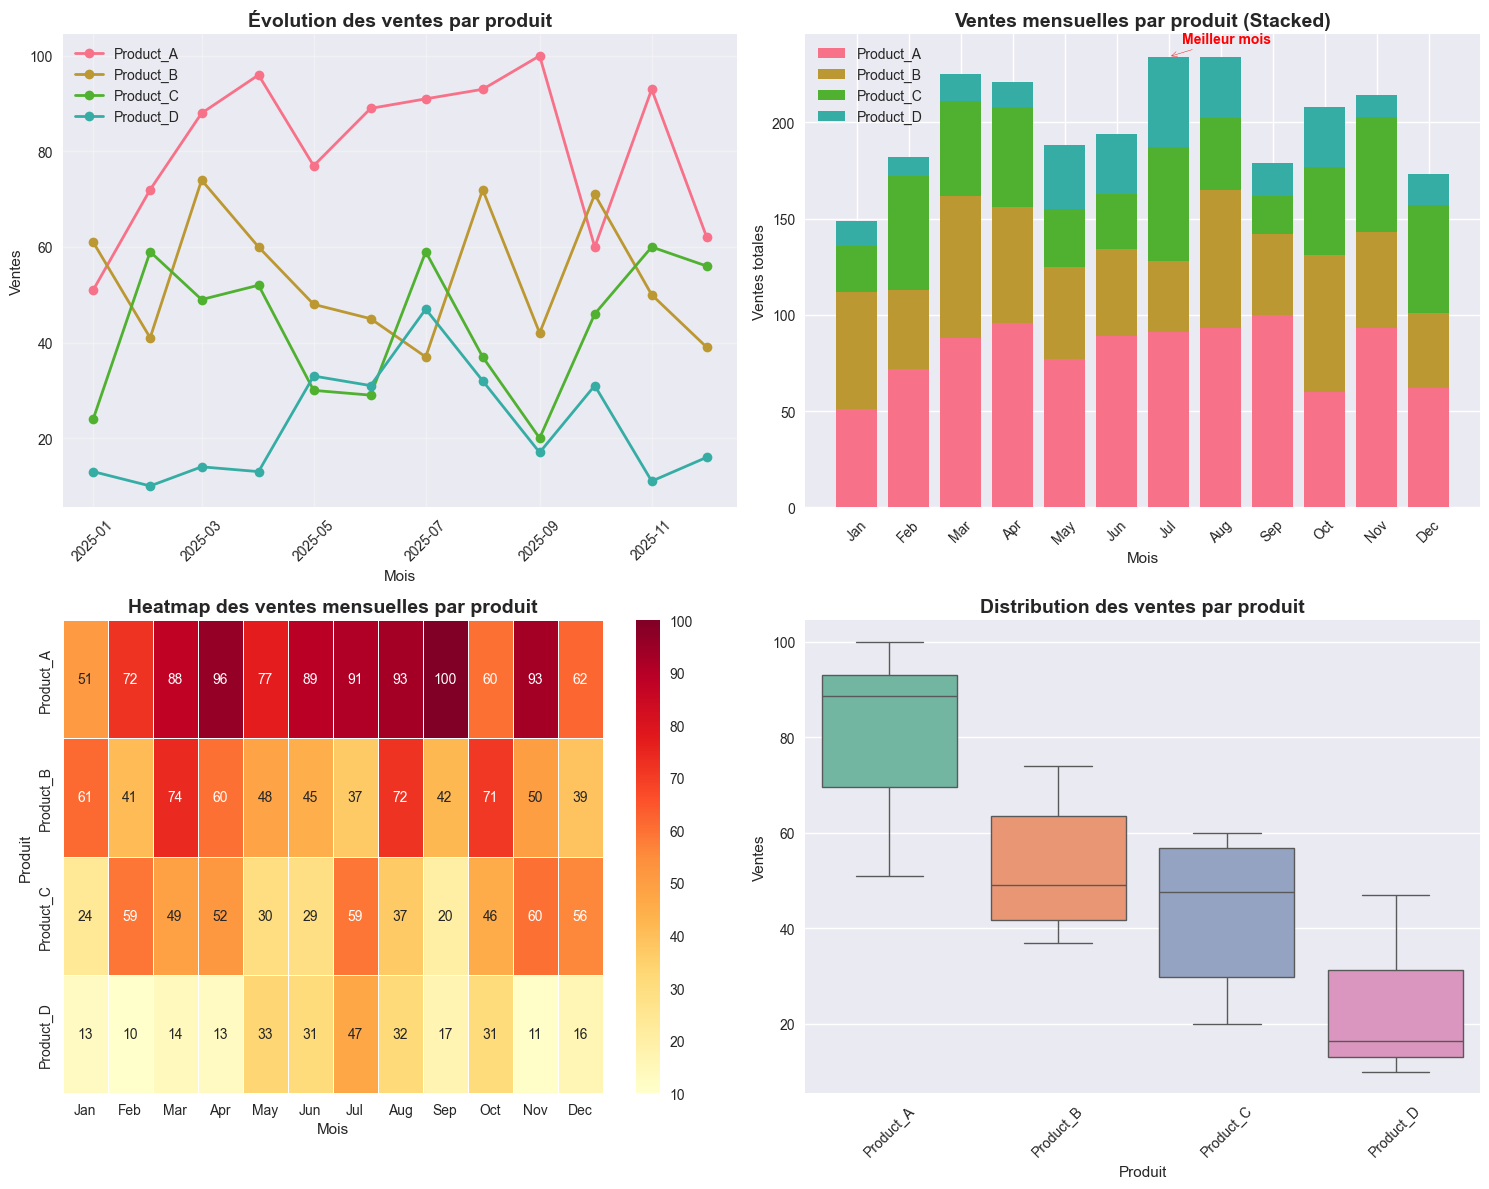

  Visualisations créées et sauvegardées dans 'data/sales_visualizations.png'
=== QUESTIONS DE CONCLUSION ===
1. PRODUIT LE PLUS IMPORTANT:
   → Product_A avec 972 ventes annuelles

2. MEILLEUR TRIMESTRE:
   → Q3 avec 647 ventes

3. RECOMMANDATIONS:
   • Se concentrer sur Product_A (notre meilleur produit)
   • Préparer plus de stock pour le trimestre Q3
   • Faire plus de publicité pendant les mois forts


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from utils import generate_random_sales


# Partie 1: Génération des données
print("=== PARTIE 1: Génération des données ===")

# Générer les dates mensuelles
dates = pd.date_range(start='2025-01-01', end='2025-12-01', freq='MS')

# Générer les ventes pour chaque produit
sales_data = {
    'Date': dates,
    'Product_A': generate_random_sales(50, 100, 12),
    'Product_B': generate_random_sales(30, 80, 12),
    'Product_C': generate_random_sales(20, 60, 12),
    'Product_D': generate_random_sales(10, 50, 12)
}

# Créer le DataFrame initial
df_initial = pd.DataFrame(sales_data)
print("DataFrame initial créé:")
print(df_initial.head())

# Sauvegarder en CSV initial
df_initial.to_csv('data/initial.csv', index=False)
print("\nFichier initial.csv sauvegardé")

# Partie 2: Construction du DataFrame avec métriques
print("\n=== PARTIE 2: Construction du DataFrame avec métriques ===")

# Créer une copie pour le DataFrame final
df_final = df_initial.copy()

# Renommer la colonne Date en Month
df_final = df_final.rename(columns={'Date': 'Month'})

# Calculer les métriques mensuelles
df_final['Total_Sales'] = df_final[['Product_A', 'Product_B', 'Product_C', 'Product_D']].sum(axis=1)
df_final['Average_Sales'] = df_final[['Product_A', 'Product_B', 'Product_C', 'Product_D']].mean(axis=1)
df_final['Month_over_Month_Growth'] = df_final['Total_Sales'].pct_change() * 100

# 4. Attribution des trimestres
def assign_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    else:
        return 'Q4'

df_final['Quarter'] = df_final['Month'].dt.month.apply(assign_quarter)

# Trouver les produits avec ventes max et min par mois
product_columns = ['Product_A', 'Product_B', 'Product_C', 'Product_D']
df_final['Max_Sales_Product'] = df_final[product_columns].idxmax(axis=1)
df_final['Min_Sales_Product'] = df_final[product_columns].idxmin(axis=1)

# Remplacer les valeurs NaN dans Month_over_Month_Growth (premier mois)
df_final['Month_over_Month_Growth'] = df_final['Month_over_Month_Growth'].fillna(0)

print("DataFrame final avec métriques:")
print(df_final.head())

# Sauvegarder le DataFrame final
df_final.to_csv('data/final.csv', index=False)
print("\nFichier final.csv sauvegardé")

# Partie 3: Tables pivots et résumés
print("\n=== PARTIE 3: Tables pivots et résumés ===")

# Table pivot: moyenne des ventes par trimestre pour chaque produit
pivot_avg_sales = pd.pivot_table(
    df_final,
    values=product_columns,
    index='Quarter',
    aggfunc='mean'
).round(2)

print("Moyenne des ventes par trimestre:")
print(pivot_avg_sales)

# Table pivot: ventes totales par trimestre
pivot_total_sales = pd.pivot_table(
    df_final,
    values='Total_Sales',
    index='Quarter',
    aggfunc='sum'
)

print("\nVentes totales par trimestre:")
print(pivot_total_sales)

# Combiner les deux tables pivots pour l'export
output_data = pivot_avg_sales.copy()
output_data['Total_Sales'] = pivot_total_sales['Total_Sales']

# Sauvegarder les résultats
output_data.to_csv('data/output.csv')
print("\nFichier output.csv sauvegardé")

# Partie 4: Insights clés
print("\n=== PARTIE 4: Insights clés ===")

# Meilleur mois (ventes totales les plus élevées)
best_month_idx = df_final['Total_Sales'].idxmax()
best_month = df_final.loc[best_month_idx]
print(f" Meilleur mois: {best_month['Month'].strftime('%B %Y')}")
print(f"   Ventes totales: {best_month['Total_Sales']}")

# Meilleur produit (ventes annuelles cumulées les plus élevées)
annual_sales_by_product = df_final[product_columns].sum()
best_product = annual_sales_by_product.idxmax()
print(f" Meilleur produit: {best_product}")
print(f"   Ventes annuelles: {annual_sales_by_product[best_product]}")

# Meilleur trimestre (ventes totales les plus élevées)
quarterly_totals = df_final.groupby('Quarter')['Total_Sales'].sum()
best_quarter = quarterly_totals.idxmax()
print(f"  Meilleur trimestre: {best_quarter}")
print(f"   Ventes totales: {quarterly_totals[best_quarter]}")

# Afficher le résumé des ventes par produit
print(f"\n  Ventes annuelles par produit:")
for product in product_columns:
    print(f"   {product}: {annual_sales_by_product[product]}")

# Partie 5: Visualisations
print("\n=== PARTIE 5: Visualisations ===")

# Configuration des graphiques
plt.figure(figsize=(15, 12))

# 1. Line chart pour chaque produit
plt.subplot(2, 2, 1)
for product in product_columns:
    plt.plot(df_final['Month'], df_final[product], marker='o', linewidth=2, label=product)

plt.title('Évolution des ventes par produit', fontsize=14, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Ventes')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2. Stacked bar chart des ventes mensuelles totales
plt.subplot(2, 2, 2)
months = df_final['Month'].dt.strftime('%b')  # Format mois abrégé
month_names = list(months)  # Convertir en liste pour l'indexation
bottom = np.zeros(12)

for product in product_columns:
    plt.bar(month_names, df_final[product], label=product, bottom=bottom)
    bottom += df_final[product].values

# Annoter le meilleur mois - CORRECTION ICI
best_month_name = df_final.loc[best_month_idx, 'Month'].strftime('%b')
best_month_index = month_names.index(best_month_name)  # Trouver l'index dans la liste
best_month_sales = df_final.loc[best_month_idx, 'Total_Sales']

plt.annotate('Meilleur mois', 
             xy=(best_month_index, best_month_sales),
             xytext=(10, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'),
             fontweight='bold', color='red')

plt.title('Ventes mensuelles par produit (Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Ventes totales')
plt.legend()
plt.xticks(rotation=45)

# 3. Heatmap des ventes mensuelles
plt.subplot(2, 2, 3)
heatmap_data = df_final[product_columns].T
heatmap_data.columns = month_names
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap des ventes mensuelles par produit', fontsize=14, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Produit')

# 4. Boxplot de la distribution des ventes
plt.subplot(2, 2, 4)
boxplot_data = df_final[product_columns]
sns.boxplot(data=boxplot_data, palette='Set2')
plt.title('Distribution des ventes par produit', fontsize=14, fontweight='bold')
plt.xlabel('Produit')
plt.ylabel('Ventes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('data/sales_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("  Visualisations créées et sauvegardées dans 'data/sales_visualizations.png'")
# Partie 6: Questions de conclusion - VERSION SIMPLE
print("=== QUESTIONS DE CONCLUSION ===")

# 1. Produit qui contribue le plus
ventes_totales = df_final[['Product_A', 'Product_B', 'Product_C', 'Product_D']].sum()
produit_meilleur = ventes_totales.idxmax()

print(f"1. PRODUIT LE PLUS IMPORTANT:")
print(f"   → {produit_meilleur} avec {ventes_totales[produit_meilleur]} ventes annuelles")

# 2. Meilleur trimestre
ventes_trimestre = df_final.groupby('Quarter')['Total_Sales'].sum()
trimestre_meilleur = ventes_trimestre.idxmax()

print(f"\n2. MEILLEUR TRIMESTRE:")
print(f"   → {trimestre_meilleur} avec {ventes_trimestre[trimestre_meilleur]} ventes")

# 3. Recommandations simples
print(f"\n3. RECOMMANDATIONS:")
print(f"   • Se concentrer sur {produit_meilleur} (notre meilleur produit)")
print(f"   • Préparer plus de stock pour le trimestre {trimestre_meilleur}")
print(f"   • Faire plus de publicité pendant les mois forts")